# Titanic Survival Prediction  
## CODSOFT Data Science Internship - Task 1

**Student Name:** Jenil Bhisra
**Internship:** CODSOFT  
**Domain:** Data Science  
**Task Number:** 1  
**Project Type:** Classification Machine Learning Project

## 1. Project Objective

The Titanic Survival Prediction project is a classic beginner-level Data Science project.  
The main goal of this project is to build a Machine Learning model that can predict whether a passenger survived the Titanic disaster or not.

The dataset contains passenger details such as:

- Passenger class
- Gender
- Age
- Number of siblings/spouses aboard
- Number of parents/children aboard
- Ticket fare
- Embarkation port
- Survival status

Since the output column **Survived** has only two values, this is a **classification problem**:

- `0` means the passenger did not survive
- `1` means the passenger survived

This type of prediction is useful in real-world problems where we need to classify outcomes, such as customer churn prediction, disease prediction, loan approval prediction, and risk analysis.

## 2. Import Required Libraries

In this section, we import all the required Python libraries for data analysis, visualization, preprocessing, model building, and model evaluation.

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 3. Load the Dataset

The dataset used for this project is the Titanic dataset downloaded from Kaggle.  
The CSV file is loaded using pandas.

In [8]:
# Load the Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Basic Dataset Information

Before building a model, it is important to understand the size, structure, columns, data types, and statistical summary of the dataset.

In [9]:
# Shape of dataset
df.shape

(891, 12)

In [10]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# Column names
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Initial Observations

From the basic dataset check:

- The dataset contains passenger-level information.
- The target column is **Survived**.
- Some columns contain missing values.
- Some columns are categorical, such as **Sex**, **Embarked**, **Name**, **Ticket**, and **Cabin**.
- Machine Learning models require numerical data, so categorical features must be converted into numeric form.

## 5. Check Missing Values

Missing values can affect the performance of a machine learning model.  
So, we check how many values are missing in each column.

In [13]:
# Check missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Missing Value Handling Plan

The dataset has missing values mainly in:

- **Age**: Fill with median age because age is numerical and median is less affected by outliers.
- **Embarked**: Fill with mode because it is categorical.
- **Cabin**: Many values are missing, so instead of using Cabin directly, we create a new feature called `Has_Cabin`.

## 6. Data Cleaning

In this section, missing values are handled and useful new features are created.

In [14]:
# Create a copy of dataset for cleaning
data = df.copy()

# Fill missing Age values with median
data["Age"].fillna(data["Age"].median(), inplace=True)

# Fill missing Embarked values with mode
data["Embarked"].fillna(data["Embarked"].mode()[0], inplace=True)

# Create a new feature to indicate whether passenger had a cabin or not
data["Has_Cabin"] = data["Cabin"].apply(lambda x: 0 if pd.isnull(x) else 1)

# Check missing values after cleaning
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Data Cleaning Observation

- Missing values in **Age** and **Embarked** have been handled.
- A new feature **Has_Cabin** was created because cabin availability may have some relationship with survival.
- The original **Cabin** column still has missing values, but it will be dropped before model training.

## 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns and relationships in the dataset using graphs and statistics.

### 7.1 Survival Count

This graph shows how many passengers survived and how many did not survive.

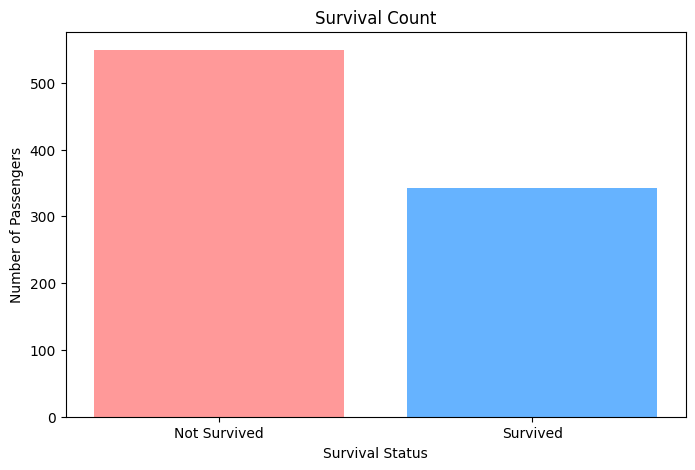

In [15]:
plt.figure(figsize=(8, 5))
survival_counts = data["Survived"].value_counts().sort_index()
plt.bar(["Not Survived", "Survived"], survival_counts.values, color=["#ff9999", "#66b3ff"])
plt.title("Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.show()

**Observation:**  
The number of passengers who did not survive is higher than the number of passengers who survived.

### 7.2 Gender vs Survival

This graph shows how survival differed between male and female passengers.

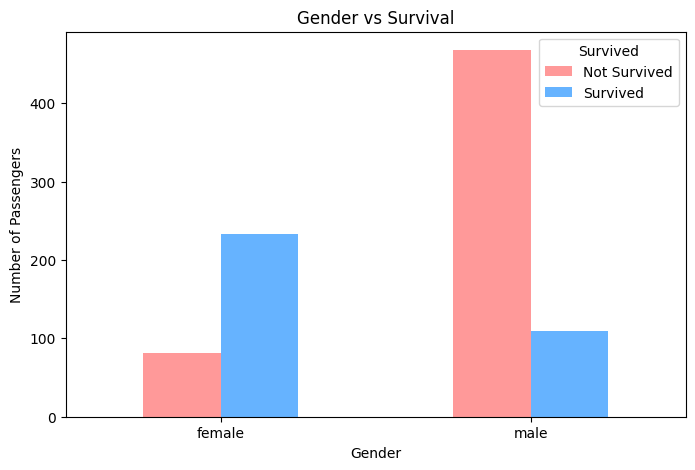

In [16]:
gender_survival = pd.crosstab(data["Sex"], data["Survived"])
gender_survival.plot(kind="bar", figsize=(8, 5), color=["#ff9999", "#66b3ff"])
plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.xticks(rotation=0)
plt.show()

**Observation:**  
Female passengers had a higher survival rate compared to male passengers.  
This indicates that gender was an important factor in survival prediction.

### 7.3 Passenger Class vs Survival

This graph shows survival based on passenger class.

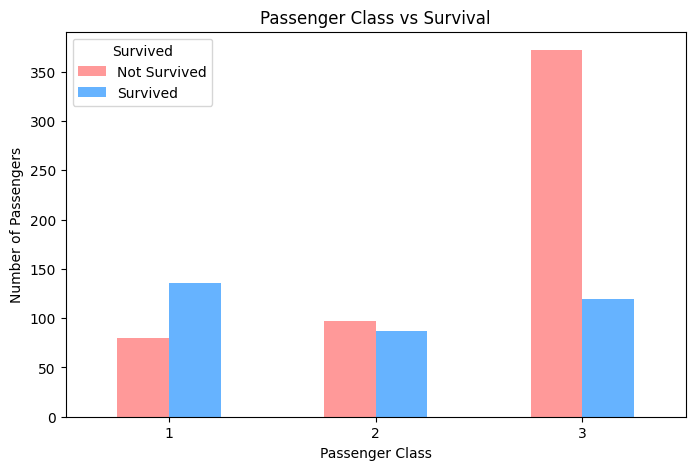

In [17]:
class_survival = pd.crosstab(data["Pclass"], data["Survived"])
class_survival.plot(kind="bar", figsize=(8, 5), color=["#ff9999", "#66b3ff"])
plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.xticks(rotation=0)
plt.show()

**Observation:**  
Passengers in 1st class had a better chance of survival compared to passengers in 2nd and 3rd class.  
This shows that passenger class played an important role in survival.

### 7.4 Age Distribution

This graph shows the distribution of passenger ages.

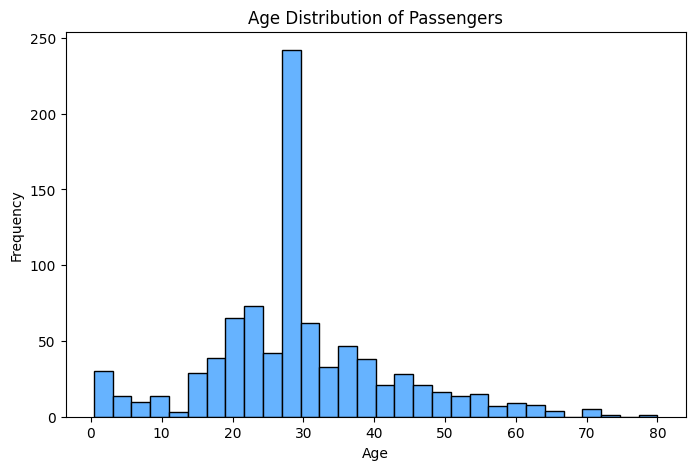

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(data["Age"], bins=30, color="#66b3ff", edgecolor="black")
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Observation:**  
Most passengers were young or middle-aged.  
Age is an important feature because children and elderly passengers may have different survival patterns.

### 7.5 Fare Distribution

This graph shows the distribution of ticket fare.

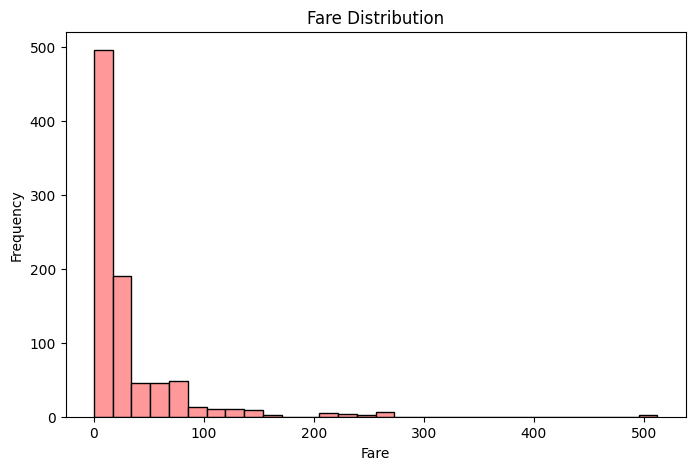

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(data["Fare"], bins=30, color="#ff9999", edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

**Observation:**  
Most passengers paid lower fares, while a few passengers paid very high fares.  
This means the Fare column is right-skewed.

### 7.6 Embarked Port vs Survival

This graph shows survival based on the port from where the passenger boarded.

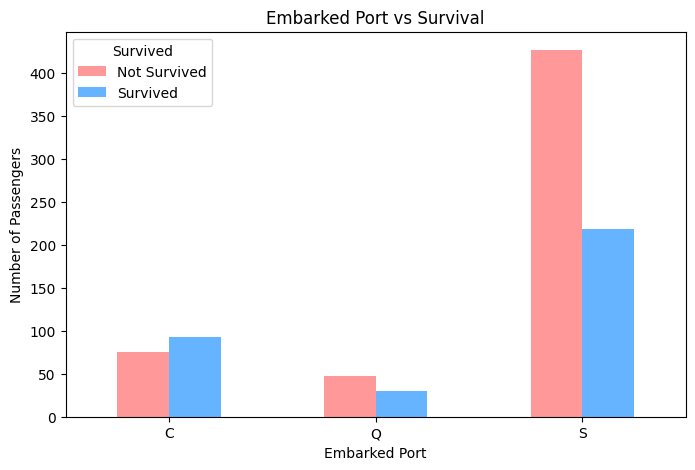

In [20]:
embarked_survival = pd.crosstab(data["Embarked"], data["Survived"])
embarked_survival.plot(kind="bar", figsize=(8, 5), color=["#ff9999", "#66b3ff"])
plt.title("Embarked Port vs Survival")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["Not Survived", "Survived"])
plt.xticks(rotation=0)
plt.show()

**Observation:**  
The survival count varies across different embarkation ports.  
This feature may help the model improve prediction accuracy.

### 7.7 Correlation Heatmap

Before creating the heatmap, categorical columns are encoded into numeric values.

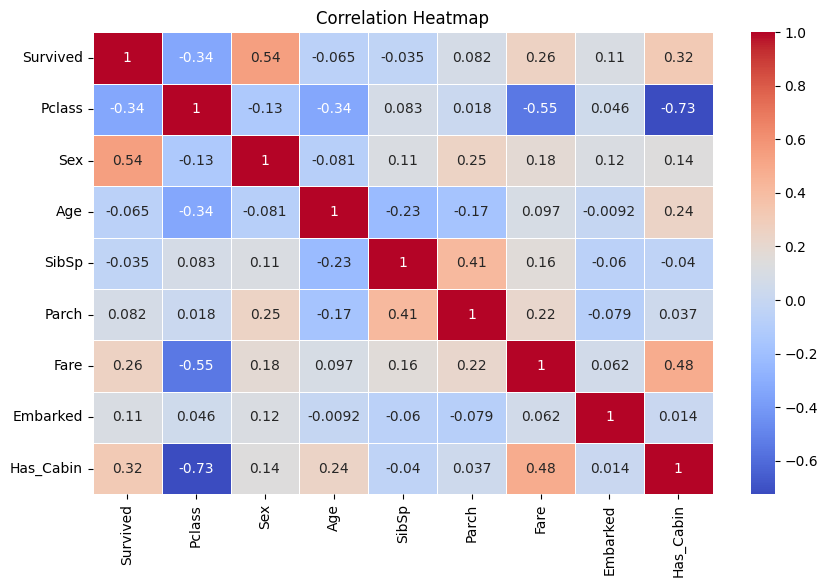

In [21]:
# Create a temporary dataframe for correlation
corr_data = data.copy()

# Convert categorical columns temporarily
corr_data["Sex"] = corr_data["Sex"].map({"male": 0, "female": 1})
corr_data["Embarked"] = corr_data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Select only useful numeric columns
corr_columns = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Has_Cabin"]

plt.figure(figsize=(10, 6))
sns.heatmap(corr_data[corr_columns].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

**Observation:**  
The heatmap helps us understand how strongly each feature is related to survival.  
Features such as **Sex**, **Pclass**, **Fare**, and **Has_Cabin** show useful relationships with survival.

## 8. Feature Engineering

Feature engineering means converting raw data into useful features for Machine Learning.

In this project:

- **Sex** is converted into numeric form.
- **Embarked** is converted into numeric form.
- **FamilySize** is created using `SibSp + Parch + 1`.
- Unnecessary columns such as **Name**, **Ticket**, and **Cabin** are removed.

In [22]:
# Encode Sex column
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})

# Encode Embarked column
data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Create FamilySize feature
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

# Drop columns that are not directly useful for model training
data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

# Display processed data
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,0,2
1,1,1,1,38.0,1,0,71.2833,1,1,2
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,1,2
4,0,3,0,35.0,0,0,8.0500,0,0,1


### Feature Engineering Explanation

- **PassengerId** is only an identification number and does not help prediction.
- **Name** may contain title information, but for a beginner-friendly project, it is removed.
- **Ticket** has too many unique values and is not directly useful.
- **Cabin** has many missing values, so we use `Has_Cabin` instead.
- **FamilySize** can help the model understand whether a passenger was alone or travelling with family.

## 9. Prepare Data for Model Training

Now we separate the dataset into:

- **X**: Independent features
- **y**: Target variable

In [23]:
# Separate features and target
X = data.drop("Survived", axis=1)
y = data["Survived"]

# Display features
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,FamilySize
0,3,0,22.0,1,0,7.2500,0,0,2
1,1,1,38.0,1,0,71.2833,1,1,2
2,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,1,2
4,3,0,35.0,0,0,8.0500,0,0,1


In [24]:
# Display target values
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


### Train-Test Split

The dataset is divided into training and testing data.

- 80% data is used for training
- 20% data is used for testing

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (712, 9)
Testing data shape: (179, 9)


## 10. Model Building

We train three different classification models:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

Then we compare their accuracy.

### 10.1 Logistic Regression

In [26]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8100558659217877


### 10.2 Decision Tree Classifier

In [27]:
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

decision_tree_pred = decision_tree_model.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

print("Decision Tree Accuracy:", decision_tree_accuracy)

Decision Tree Accuracy: 0.7932960893854749


### 10.3 Random Forest Classifier

In [28]:
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

random_forest_pred = random_forest_model.predict(X_test)
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)

print("Random Forest Accuracy:", random_forest_accuracy)

Random Forest Accuracy: 0.8156424581005587


## 11. Model Comparison

Now we compare all three models based on accuracy.

In [29]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [logistic_accuracy, decision_tree_accuracy, random_forest_accuracy]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.793296
2,Random Forest,0.815642


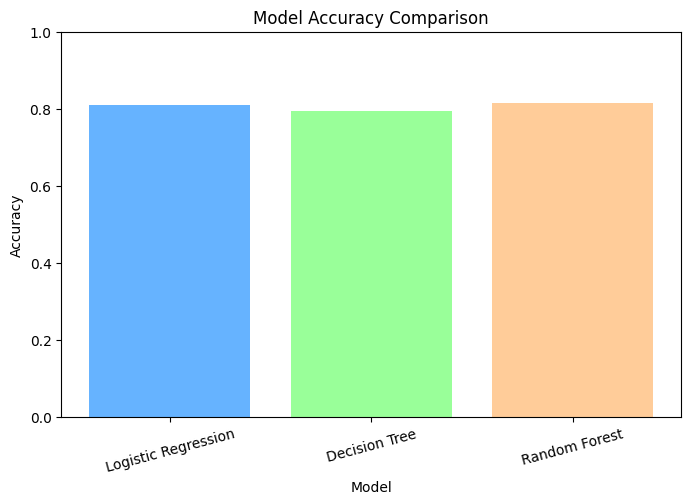

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(model_comparison["Model"], model_comparison["Accuracy"], color=["#66b3ff", "#99ff99", "#ffcc99"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### Model Comparison Observation

The model with the highest accuracy is selected as the best model.  
Accuracy shows how many predictions were correct out of total predictions.

In [31]:
# Select best model automatically
accuracies = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": decision_tree_accuracy,
    "Random Forest": random_forest_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Random Forest
Best Accuracy: 0.8156424581005587


## 12. Best Model Selection

The best model is selected based on the highest accuracy score.

For this dataset, the best model is identified automatically from the model comparison table.  
A good model should not only give high accuracy but should also generalize well on unseen data.

In [32]:
# Store best model and prediction
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_pred = logistic_pred
elif best_model_name == "Decision Tree":
    best_model = decision_tree_model
    best_pred = decision_tree_pred
else:
    best_model = random_forest_model
    best_pred = random_forest_pred

print("Selected Best Model:", best_model_name)

Selected Best Model: Random Forest


## 13. Confusion Matrix

A confusion matrix helps us understand correct and incorrect predictions.

It shows:

- **True Negative (TN):** Actually not survived and predicted not survived
- **False Positive (FP):** Actually not survived but predicted survived
- **False Negative (FN):** Actually survived but predicted not survived
- **True Positive (TP):** Actually survived and predicted survived

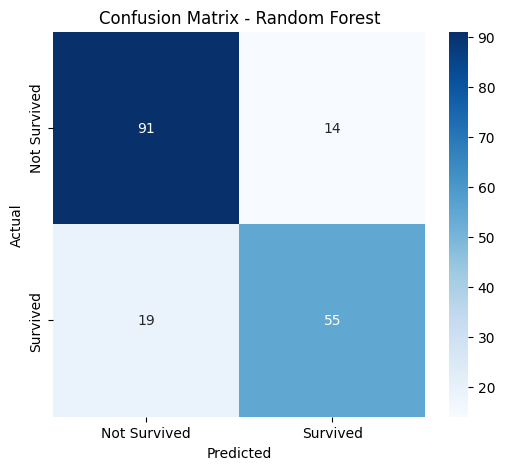

In [33]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 14. Classification Report

The classification report gives more detailed performance metrics:

- **Precision:** How many predicted positive cases were actually positive
- **Recall:** How many actual positive cases were correctly predicted
- **F1-score:** Balance between precision and recall
- **Support:** Number of actual samples in each class

In [34]:
print("Classification Report for", best_model_name)
print(classification_report(y_test, best_pred))

Classification Report for Random Forest
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



## 15. Feature Importance

For tree-based models like Decision Tree and Random Forest, feature importance shows which columns contributed more to prediction.

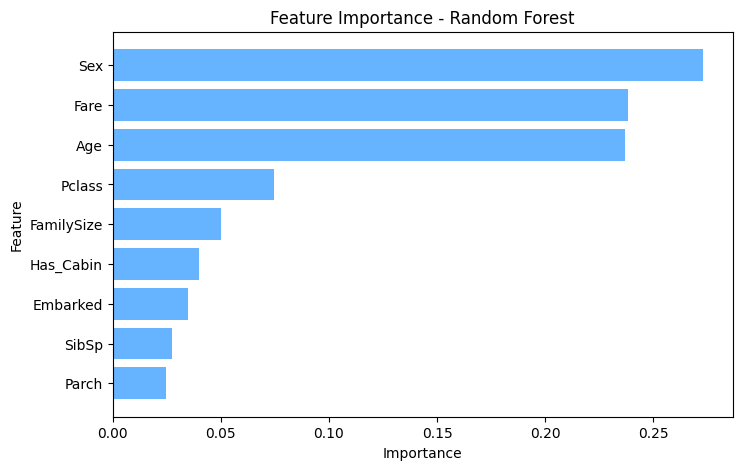

,Feature,Importance
1,Sex,0.273047
5,Fare,0.238192
2,Age,0.237021
0,Pclass,0.074453
8,FamilySize,0.050077
7,Has_Cabin,0.040152
6,Embarked,0.034944
3,SibSp,0.027665
4,Parch,0.024449


In [35]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 5))
    plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="#66b3ff")
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    display(feature_importance)
else:
    print("Feature importance is not directly available for this model.")

## 16. Sample Prediction

Now we test the final model using sample passenger details.

The sample passenger data must have the same columns as the training data.

In [36]:
# Create sample passenger data
sample_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [0],          # 0 = male, 1 = female
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [0],     # 0 = S, 1 = C, 2 = Q
    "Has_Cabin": [0],
    "FamilySize": [1]
})

sample_prediction = best_model.predict(sample_passenger)

if sample_prediction[0] == 1:
    print("Prediction: Passenger likely survived.")
else:
    print("Prediction: Passenger likely did not survive.")

Prediction: Passenger likely did not survive.


## 17. Final Conclusion

In this project:

- The Titanic dataset was successfully loaded and analyzed.
- Missing values were identified and handled properly.
- Exploratory Data Analysis was performed using multiple visualizations.
- Important patterns were observed in gender, class, age, fare, and embarked columns.
- Categorical features were converted into numerical format.
- A new feature called **FamilySize** was created.
- Three Machine Learning models were trained:
  - Logistic Regression
  - Decision Tree Classifier
  - Random Forest Classifier
- Model performance was compared using accuracy.
- The best model was selected based on highest accuracy.
- Confusion matrix and classification report were used for detailed evaluation.
- A sample prediction was performed successfully.
- The objective of predicting Titanic passenger survival was achieved.

This notebook is ready for CODSOFT Data Science Internship Task 1 submission.